# Statistical Methods in Imaging (SMI) Conference, 2026.
# Empowering Large Language Models with Statistics: A Practical Tutorial for Medical Imaging
**Ernest (Khashayar) Namdar, Dominik A. Deniffel, Pascal Tyrrell**

This notebook evaluates the probabilistic output from the Decoder LLM using three distinct probability thresholding methods to convert raw probabilities into hard binary classifications.

The B-point method referenced here was introduced in our paper:
```bibtex
@inproceedings{namdar2024advanced,
   author = {Khashayar Namdar and Farzad Khalvati},
   booktitle = {IEEE-EMBS International Conference on Biomedical and Health Informatics},
   title = {Advanced Receiver Operating Characteristic Curve Analysis to Identify Outliers in Binary Machine Learning Classifications for Precision Medicine},
   url = {https://openreview.net/forum?id=9VCv8bLKdq},
   year = {2024}
}
```


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------
# 1. Load Data
# ------------------------
ais_path = '../../Part2_Decoder_LLM_for_Classification/data/AIS.csv'
preds_path = '../../Part2_Decoder_LLM_for_Classification/results/LM_pydantic_inference.csv'

df_labels = pd.read_csv(ais_path)[['ID', 'Label']]
df_preds = pd.read_csv(preds_path)

# Merge and drop rows where LLM probabilities are missing
df = df_labels.merge(df_preds, left_on='ID', right_on='Id')
df = df.dropna(subset=['Prob_Yes'])

y_true = df['Label'].values
y_prob = df['Prob_Yes'].values


## Threshold Calculation

We evaluate three methods:
1. **0.5 Threshold**: Standard binary cutoff.
2. **J Point**: Youden's J Statistic, which maximizes $TPR - FPR$.
3. **B Point**: Intersection of the B-line ($y = -mX + 1$) with the ROC curve, where $m = N_{negative} / N_{positive}$. We find this by minimizing the absolute difference $|TPR + m \cdot FPR - 1|$ across all points on the empirical ROC curve.

In [4]:
# ------------------------
# 2. Calculate Thresholds
# ------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# Method 1: 0.5 Threshold
thresh_05 = 0.5

# Method 2: J Point
j_scores = tpr - fpr
j_idx = np.argmax(j_scores)
thresh_J = thresholds[j_idx]

# Method 3: B Point
n_pos = np.sum(y_true == 1)
n_neg = np.sum(y_true == 0)
m = n_neg / n_pos

# B line formula in ROC space (X=fpr, Y=tpr): Y = -m*X + 1 => Y + m*X - 1 = 0
# We find the point on the ROC curve that minimizes this difference
b_distances = np.abs(tpr + m * fpr - 1)
b_idx = np.argmin(b_distances)
thresh_B = thresholds[b_idx]

print(f"Calculated Thresholds:")
print(f"Standard 0.5: {thresh_05:.4f}")
print(f"J Point:      {thresh_J:.4f}")
print(f"B Point:      {thresh_B:.4f}")


Calculated Thresholds:
Standard 0.5: 0.5000
J Point:      0.1645
B Point:      0.9466


In [5]:
# ------------------------
# 3. Metrics Calculation
# ------------------------
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
    return accuracy, sensitivity, specificity, precision, f1

y_pred_05 = (y_prob >= thresh_05).astype(int)
y_pred_J = (y_prob >= thresh_J).astype(int)
y_pred_B = (y_prob >= thresh_B).astype(int)

metrics_05 = get_metrics(y_true, y_pred_05)
metrics_J = get_metrics(y_true, y_pred_J)
metrics_B = get_metrics(y_true, y_pred_B)

metrics_df = pd.DataFrame(
    [metrics_05, metrics_J, metrics_B],
    columns=['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score'],
    index=['Threshold=0.5', 'J Point', 'B Point']
)
display(metrics_df.round(4))


,Accuracy,Sensitivity,Specificity,Precision,F1 Score
Threshold=0.5,0.9286,0.9491,0.9252,0.6788,0.7915
J Point,0.9144,0.9931,0.9012,0.6263,0.7681
B Point,0.9375,0.7778,0.9641,0.7832,0.7805


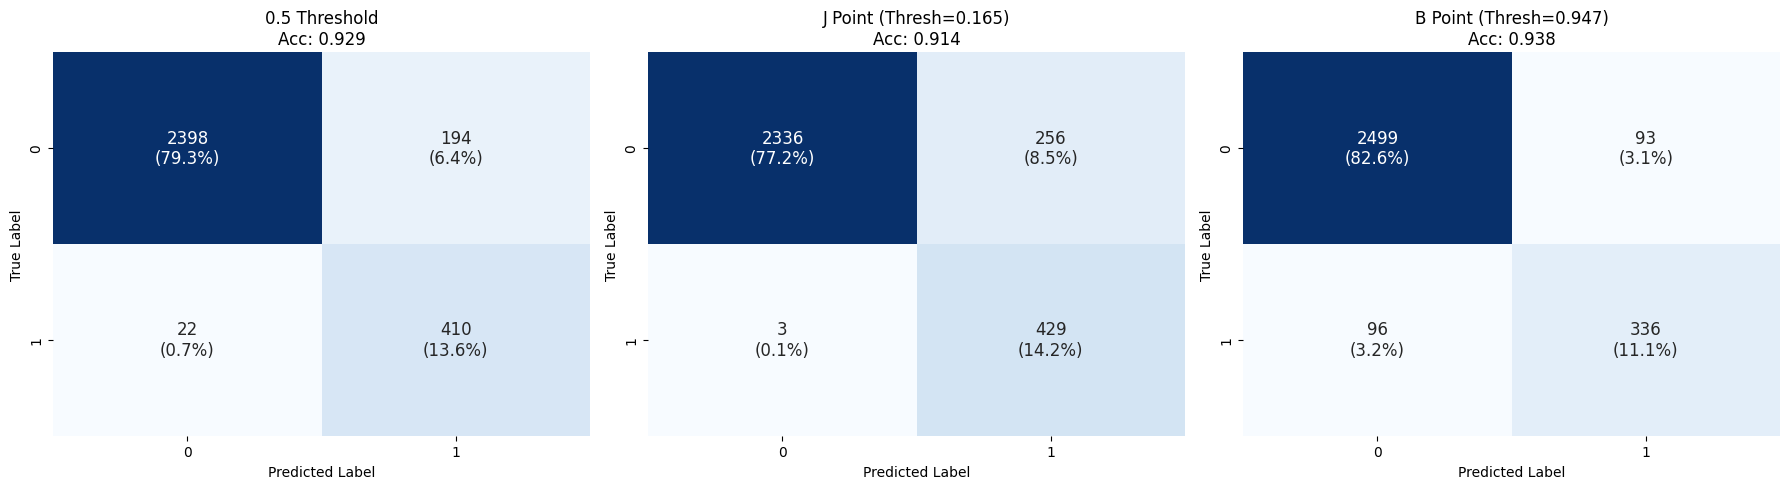

In [6]:
# ------------------------
# 4. Visualizations
# ------------------------
def plot_cm(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_perc = cm / cm.sum()
    annot = np.empty_like(cm).astype(str)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f"{cm[i, j]}\n({cm_perc[i, j]*100:.1f}%)"
            
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax, cbar=False, annot_kws={"size": 12})
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cm(y_true, y_pred_05, axes[0], f'0.5 Threshold\nAcc: {metrics_05[0]:.3f}')
plot_cm(y_true, y_pred_J, axes[1], f'J Point (Thresh={thresh_J:.3f})\nAcc: {metrics_J[0]:.3f}')
plot_cm(y_true, y_pred_B, axes[2], f'B Point (Thresh={thresh_B:.3f})\nAcc: {metrics_B[0]:.3f}')

plt.tight_layout()
plt.show()


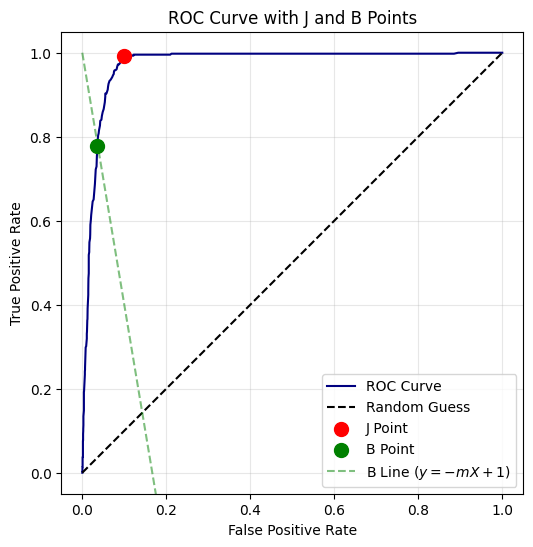

In [7]:
# Bonus Plot: ROC Curve with Threshold Points
plt.figure(figsize=(6, 6))
plt.gca().set_aspect('equal', adjustable='box')
plt.plot(fpr, tpr, label='ROC Curve', color='navy')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Plot the J Point
plt.scatter(fpr[j_idx], tpr[j_idx], color='red', s=100, zorder=5, label='J Point')

# Plot the B Point
plt.scatter(fpr[b_idx], tpr[b_idx], color='green', s=100, zorder=5, label='B Point')

# Plot the B Line (Y = -m*X + 1)
x_vals = np.array([0, 1])
y_vals = -m * x_vals + 1
plt.plot(x_vals, y_vals, 'g--', alpha=0.5, label='B Line ($y = -mX + 1$)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with J and B Points')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.show()
